In [24]:
import math
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("D:/PhD_Oriane/simulations_STICS/simulations_stics_paper_1/simulations_stics_papier_1")

In [72]:
def read_sti_file(file_sti, ref=False, density=5.4, conv_unit=100, end=-1):
    """Reads a STICS mod_s*.sti output file and builds a dictionary.
    """
    
    data_dict = {}
    non_zero_height_encountered = False

    with open(file_sti) as file:  # noqa: PTH123
        # Read the header line to get column names
        header = file.readline().strip().split(",")
        # Strip whitespace from column names
        stripped_header = [col.strip() for col in header if col != 'pla']

        # Initialize empty lists for each selected column in the dictionary
        data_dict = {col.strip(): [] for col in stripped_header}

        # Read the rest of the lines (data rows)
        for line in file:
            values = line.strip().split(",")
            row = {col.strip(): float(value) if col.strip() != "Date" else value for col, value in zip(stripped_header, values)}
            # if row["hauteur"] > 0.0 and row["lai_n"] > 0.0:

            #     non_zero_height_encountered = True

            for col in stripped_header:
                data_dict[col.strip()].append(row[col.strip()])

            # if non_zero_height_encountered and (row["hauteur"] <= 0.0 or row["lai_n"] <= 0.0):
            #     break

    if ref:
        angle = None
    else:
        angle = list(data_dict["angle"]) 
    date = list(data_dict["Date"])
    lai = list(data_dict["lai_n"])
    height = list(data_dict["hauteur"])
    par_abs = list(data_dict["fapar"]) # to % of light intercepted, in MJ/m^2
    biomass = list(data_dict["masec_n"]) 
    biomass_yield = list(data_dict["mafruit"]) 
    demand = list(data_dict["demande"])

    return angle, date, lai, height, par_abs, biomass, biomass_yield, demand

In [73]:
file_sti = "D:/PhD_Oriane/simulations_STICS/simulations_stics_paper_1/simulations_stics_papier_1/simulations_angles.csv"
angle, date, lai, height, fapar, biomass, y, demand = read_sti_file(file_sti)

file_sti_ref = "D:/PhD_Oriane/simulations_STICS/simulations_stics_paper_1/simulations_stics_papier_1/simulations_reference.csv"
angle_ref, date_ref, lai_ref, height_ref, fapar_ref, biomass_ref, y_ref, demand_ref = read_sti_file(file_sti_ref, ref=True)

faPAR:13%
Aboveground dry biomass:6%
Yield dry biomass:1%


Text(0, 0.5, 'Relative variability (%)')

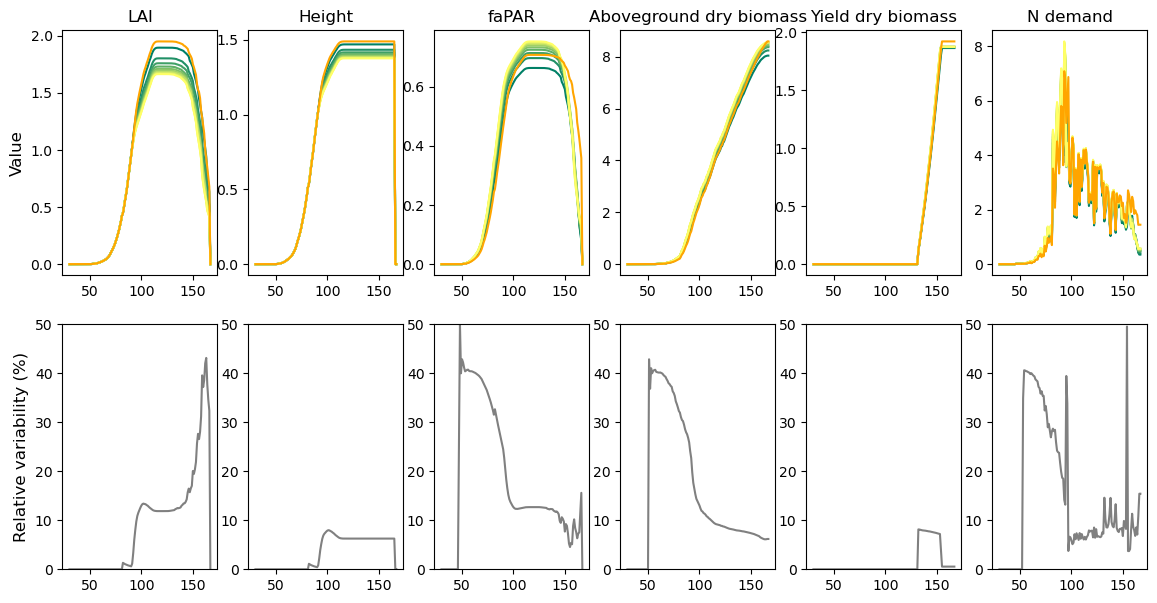

In [102]:
angle = [10,20,30,40,50,60,70,80,90]
dae = range(int(len(date)/9))

start = 30
end = 168

norm = plt.Normalize(10, 90)
cmap = plt.get_cmap('summer')

fig, ax = plt.subplots(2,6, figsize=(14,7))
i = 0
for value,ref,name in zip([lai, height, fapar, biomass, y, demand], [lai_ref, height_ref, fapar_ref, biomass_ref, y_ref, demand_ref], ["LAI", "Height", "faPAR", "Aboveground dry biomass", "Yield dry biomass", "N demand"]):
    cum_v = []
    vs = []
    for j, theta in enumerate(angle):
        color = cmap(norm(theta))
        v = value[j*len(dae):(j+1)*len(dae)]
        ax[0,i].plot(dae[start:end],v[start:end], color=color)
        vs.append(v)
        cum_v.append(np.cumsum(v[start:end]))
    ax[0,i].plot(dae[start:end],ref[start:end], color="orange")
    ax[0,i].set_title(name, fontsize=12)
    var_abs = [(max([c[t] for c in vs]) - min([c[t] for c in vs])) / ref[t] * 100 if ref[t]>1e-6 else 0 for t in range(len(v))]
    ax[1,i].plot(dae[start:end],var_abs[start:end], color="grey")
    ax[1,i].set_ylim([0,50])
    var_cum = (max([c[-1] for c in cum_v]) - min([c[-1] for c in cum_v])) / np.cumsum(ref)[-1] * 100
    if "biomass" in name:
        print(f"{name}:{var_abs[-1]:.0f}%")
    elif name == "faPAR":
        print(f"{name}:{var_cum:.0f}%")

    if name == "Height":
        ax[0,i].set_yticks([0.0,0.5,1.0,1.5])
        
    i += 1


ax[0,0].set_ylabel("Value", fontsize=12)
ax[1,0].set_ylabel("Relative variability (%)", fontsize=12)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
# cbar.set_label(r"$\theta_{leaf}$", fontsize=14)
# cbar.set_ticks([min(angle), max(angle)])
# cbar.set_ticklabels([f"{min(angle)}", f"{max(angle)}"], fontsize=14)
